# BANKING PROJECT
**Goal:**
> To Use Machine Learning Algorithm  to predict whether a customer  will subscribe to a term deposit based on demographic ,financial,  and compaign-related attributes

In [1]:
# Importing Data Analysis Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading the dataset

bnk_dataset = pd.read_excel("/content/Banking_Call_Data.xlsx")
#printing the structure of the dataset
bnk_dataset.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Reviewing the shape of the dataset
print(f" Number of the rows: {bnk_dataset.shape[0]}")
print(f" Number of the coloums: {bnk_dataset.shape[1]}")

 Number of the rows: 45211
 Number of the coloums: 17


In [5]:
# Reviewing the dataset Information
bnk_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
# Displaying the Numerical and Categorical Columns

num_columns = bnk_dataset.select_dtypes(include = np.number).columns.to_list()
print("Numerical Columns:")
print(num_columns)

cat_columns = bnk_dataset.select_dtypes(include = ['object','category']).columns.to_list()
print("\nCategorical Columns:")
print(cat_columns)

Numerical Columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [7]:
# Iterating through the categorical columns only
for cols in cat_columns:
  #Displaying the column names
  print(f"\nUnique values in {cols}")

  # Displaying the unique values
  print(bnk_dataset[cols].unique())

  # Displaying the count of the unique values
  print(f"Count: {bnk_dataset[cols].nunique()}")



Unique values in job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Count: 12

Unique values in marital
['married' 'single' 'divorced']
Count: 3

Unique values in education
['tertiary' 'secondary' 'unknown' 'primary']
Count: 4

Unique values in default
['no' 'yes']
Count: 2

Unique values in housing
['yes' 'no']
Count: 2

Unique values in loan
['no' 'yes']
Count: 2

Unique values in contact
['unknown' 'cellular' 'telephone']
Count: 3

Unique values in month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
Count: 12

Unique values in poutcome
['unknown' 'failure' 'other' 'success']
Count: 4

Unique values in y
['no' 'yes']
Count: 2


In [8]:
# Checking for the missing values in the dataset
print("The Missing/Null values in the Dataset is :\n",bnk_dataset.isnull().sum())

The Missing/Null values in the Dataset is :
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [9]:
# Checking for the duplicate values in the dataset
print("The Duplicate values in the dataset:\n",bnk_dataset.duplicated().sum())

The Duplicate values in the dataset:
 0


In [10]:
# Renaming the target variable 'y' to 'is_claim'

bnk_dataset.rename(columns= {'y': 'is_claim'}, inplace = True)

In [11]:
bnk_dataset.head(2)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,is_claim
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no


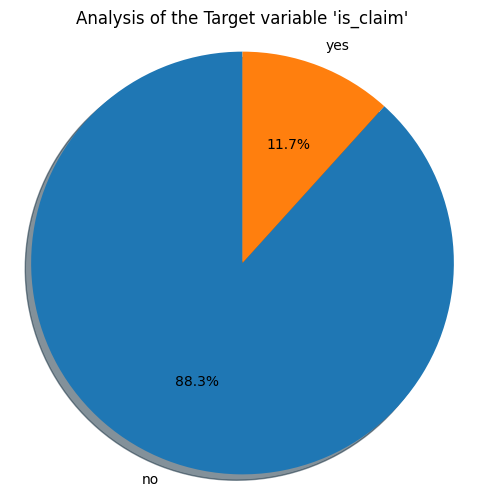

In [12]:
# Analysing the target variable 'is_claim' through visualization
# Using the pie chart

plt.figure(figsize = (6, 6))
plt.pie(bnk_dataset['is_claim'].value_counts(), labels = bnk_dataset['is_claim'].value_counts().index,
        autopct='%1.1f%%', startangle=90, shadow=True)

# Add a title
plt.title("Analysis of the Target variable 'is_claim'")

#Ensure the circle is drawn as circle
plt.axis('equal')

# Display the chart
plt.show()

In [13]:
# Summary of the Descriptive Statistics
bnk_dataset.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


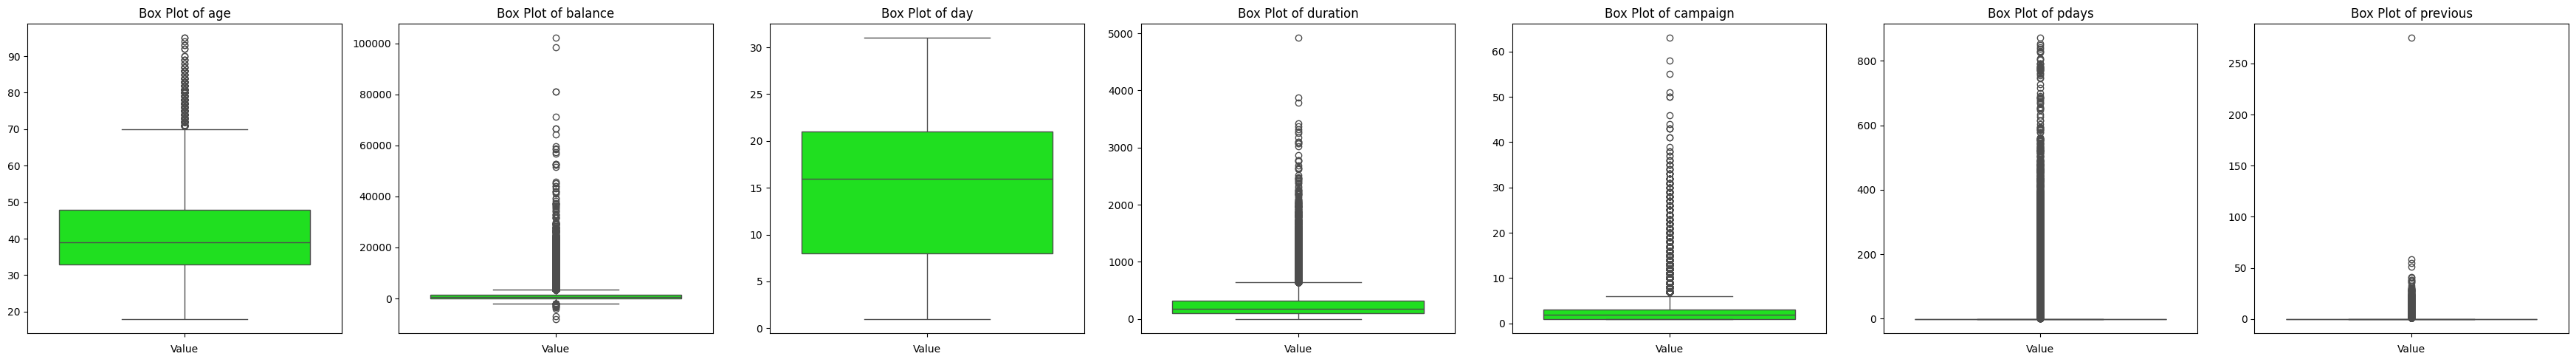

In [14]:
# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, len(num_columns), figsize=(5 * len(num_columns), 5))

# If only one column, make axes iterable
if len(num_columns) == 1:
    axes = [axes]

# Iterate and plot
for i, col in enumerate(num_columns):
    sns.boxplot(
        y=bnk_dataset[col],
        ax=axes[i],
        orient='h',
        color="lime"
    )
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

In [15]:
# Capping the outliers in all the numerical values using IQR method
def cap_outliers_IQR(bnk_dataset):
  for cols in num_columns:
    Q1 = bnk_dataset[cols].quantile(0.25)
    Q3 = bnk_dataset[cols].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # cap the values
    bnk_dataset[cols] = np.clip(bnk_dataset[cols], lower_bound, upper_bound)
  return bnk_dataset
bnk_dataset = cap_outliers_IQR(bnk_dataset)

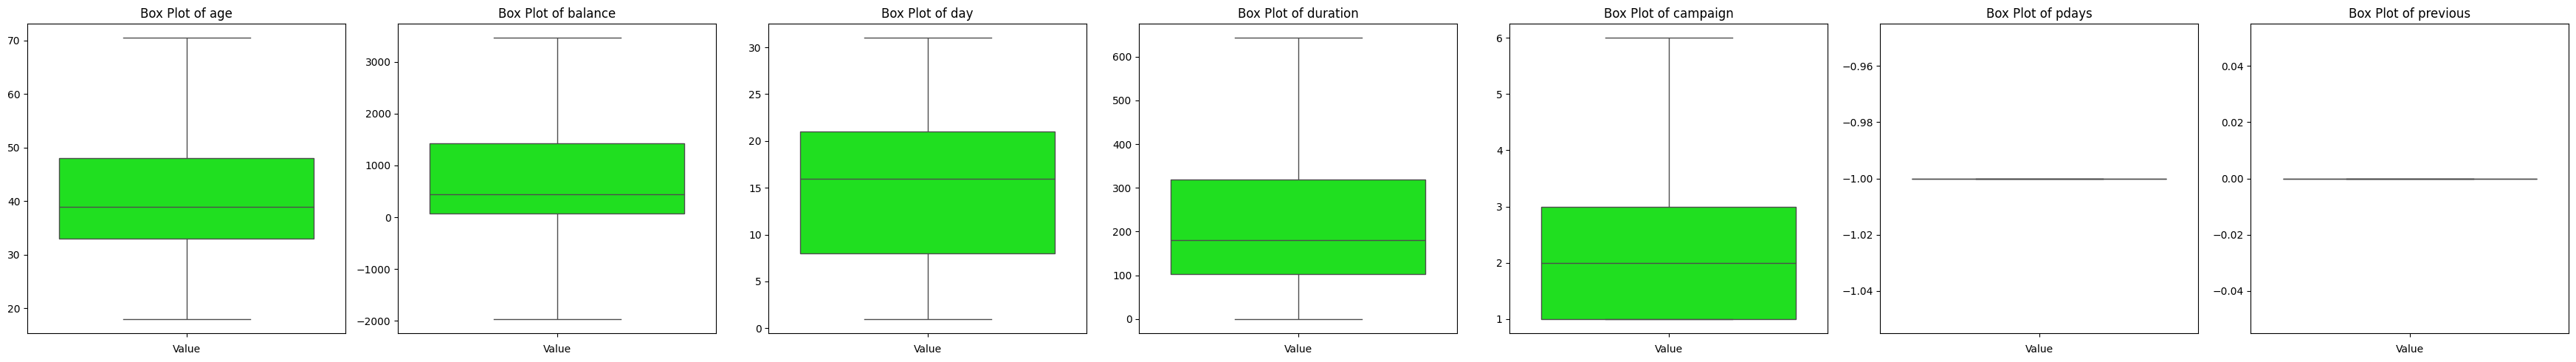

In [16]:
# Create subplots: 1 row, 3 columns
fig, axes = plt.subplots(1, len(num_columns), figsize=(5 * len(num_columns), 5))

# If only one column, make axes iterable
if len(num_columns) == 1:
    axes = [axes]

# Iterate and plot
for i, col in enumerate(num_columns):
    sns.boxplot(
        y=bnk_dataset[col],
        ax=axes[i],
        orient='h',
        color="lime"
    )
    axes[i].set_title(f'Box Plot of {col}')
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

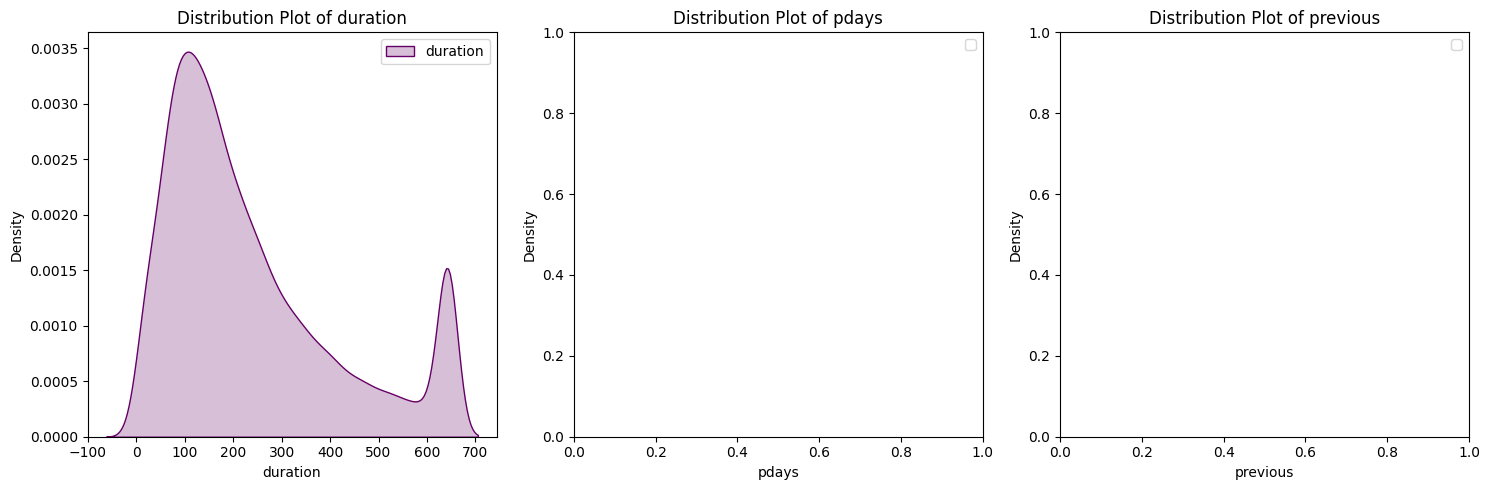

In [17]:
# Create 1 row, 3 columns of subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loop through columns and plot
columns = ['duration','pdays','previous']
for i, col in enumerate(columns):
    sns.kdeplot(bnk_dataset[col], color='#660066', shade=True, label=col, ax=axes[i])
    axes[i].set_title(f'Distribution Plot of {col}')
    axes[i].legend() # Add legend to each subplot

plt.tight_layout()
plt.show()

In [18]:
# Visualizing : Job Description of the client in the bank

import plotly.express as px

# Create the DataFrame for plotting
job_counts_df = bnk_dataset.job.value_counts().reset_index()
job_counts_df.columns = ['Job Category', 'Count']

# Plot using plotly.express
fig = px.bar(
    job_counts_df,
    x='Job Category',
    y='Count',
    color='Job Category',
    text='Count',
    template='simple_white'
)

fig.update_traces(marker=dict(line=dict(color="#000000", width=1.2)))

fig.update_layout(
    width=650,                # reduced width
    height=420,               # reduced height
    title_x=0.5,
    title_text='<b>Job Type of the Customers',
    font_family="Times New Roman",
    title_font_family="Times New Roman",
    xaxis_tickangle=-35       # improves readability
)

fig.show()


Management and Blue-collar Job type Clients are maximum in the bank
There are very less number of student and unknown customers in the bank

In [19]:
# Visualizing : Marital clients in this bank

import plotly.express as px

# Create the DataFrame for plotting
marital_counts_df = bnk_dataset.marital.value_counts().reset_index()
marital_counts_df.columns = ['Marital-Status', 'Count']

fig = px.pie(
    marital_counts_df,
    names='Marital-Status',
    values='Count',
    hole=0.5,
    template='plotly_white',
    color_discrete_sequence=['HotPink', 'LightSeaGreen', 'SlateBlue']
)

fig.update_traces(
    marker=dict(line=dict(color='#000000', width=1.4)),
    textposition='outside',
    textinfo='percent+label'
)

fig.update_layout(
    width=500,                 # reduced size
    height=420,
    title_text='<b>Marital Status of the Customers',
    title_x=0.5,
    showlegend=True,
    legend_title_text='<b>Marital Status',
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1
    ),
    font_family="Times New Roman",
    title_font_family="Times New Roman"
)

fig.show()

Most of the clients in the bank are Married - 60.2%

In [20]:
# Visualizing : Educated clients in the bank

# Create the DataFrame for plotting with explicit column naming
education_counts_df = bnk_dataset.education.value_counts().reset_index()
education_counts_df.columns = ['Education', 'Count']

fig = px.bar(
    education_counts_df,
    x='Education',
    y='Count',
    color='Education',
    text='Count',
    template='plotly_white'
)

fig.update_traces(marker=dict(line=dict(color='#000000', width=1.4)))

fig.update_layout(
    width=600,          # reduce width
    height=400,         # reduce height
    title_x=0.5,
    legend_title_text='<b>Education',
    title_text='<b>Education of the customers',
    font_family="Times New Roman",
    title_font_family="Times New Roman"
)

fig.show()

Most of the customers in the bank are related to Secondary - 49.1% and Tertiary - 33% Category
only 13.4% of the clients are related to primary education category

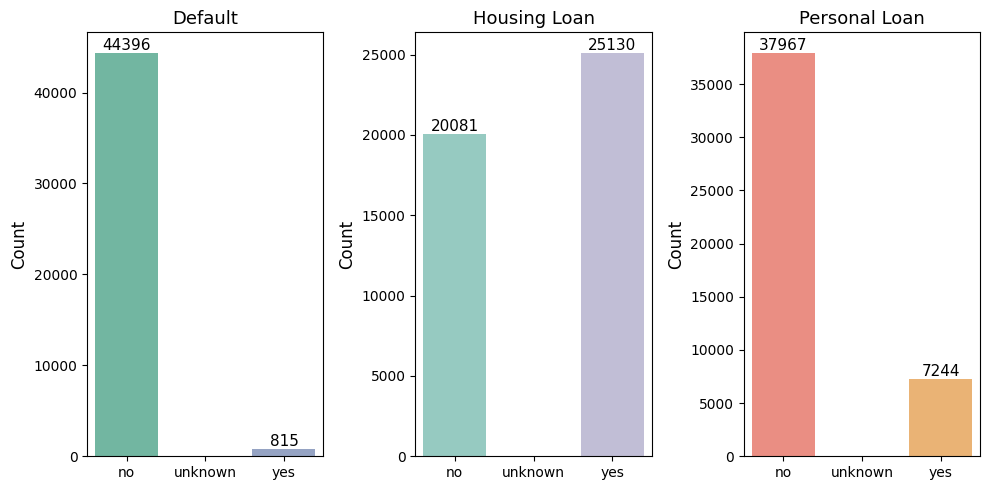

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Smaller figure size
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3, figsize=(10, 5)
)

# Color palettes
default_colors = ['#66c2a5', '#fc8d62', '#8da0cb']
housing_colors = ['#8dd3c7', '#ffffb3', '#bebada']
loan_colors    = ['#fb8072', '#80b1d3', '#fdb462']

# Default
sns.countplot(
    x='default',
    data=bnk_dataset,
    ax=ax1,
    order=['no', 'unknown', 'yes'],
    palette=default_colors
)
ax1.set_title('Default', fontsize=13)
ax1.set_xlabel('')
ax1.set_ylabel('Count', fontsize=12)

# Housing
sns.countplot(
    x='housing',
    data=bnk_dataset,
    ax=ax2,
    order=['no', 'unknown', 'yes'],
    palette=housing_colors
)
ax2.set_title('Housing Loan', fontsize=13)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=12)

# Loan
sns.countplot(
    x='loan',
    data=bnk_dataset,
    ax=ax3,
    order=['no', 'unknown', 'yes'],
    palette=loan_colors
)
ax3.set_title('Personal Loan', fontsize=13)
ax3.set_xlabel('')
ax3.set_ylabel('Count', fontsize=12)

# Function to add value labels
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom',
            fontsize=11
        )

# Apply labels
add_labels(ax1)
add_labels(ax2)
add_labels(ax3)

plt.tight_layout()
plt.show()


BANK CLIENTS CONCLUSION
The ages dont mean to much, has a medium dispersion and dont make sense relate with other variables will not tell any insight

Jobs, Marital and Education i think the best analisys is just the count of each variable, if we related with the other ones its is not conclusive, all this kind of variables has yes, unknown and no for loan, default and housing.

Default, loan and housing, its just to see the distribution of people.

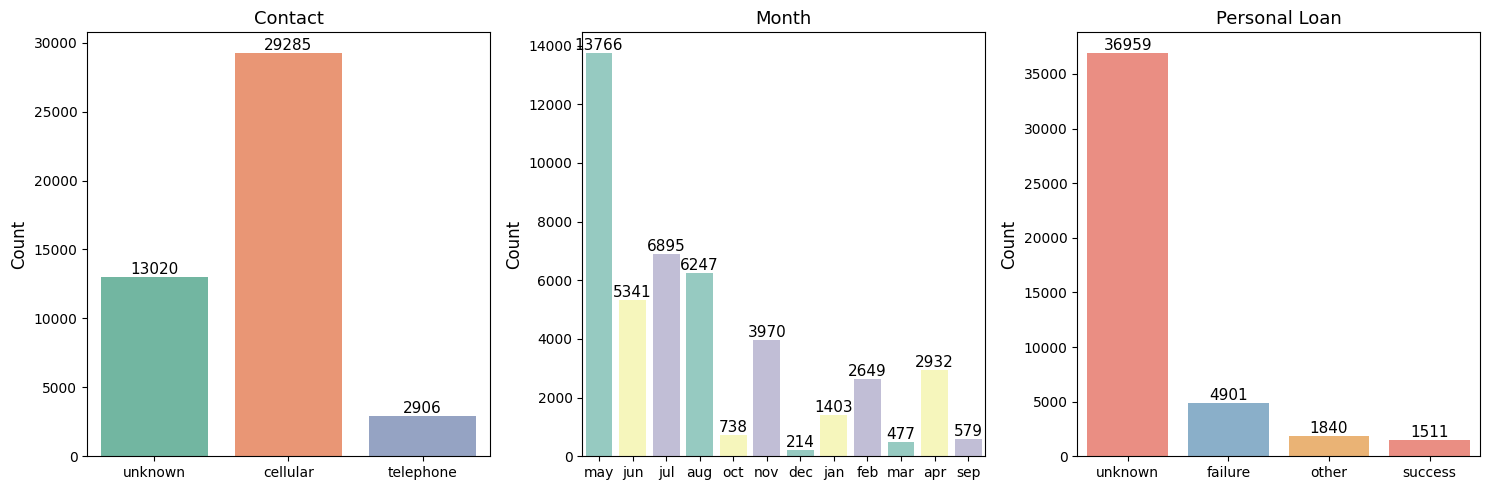

In [22]:
# Smaller figure size
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 5)
)

# Color palettes
contact_colors = ['#66c2a5', '#fc8d62', '#8da0cb']
month_colors = ['#8dd3c7', '#ffffb3', '#bebada']
day_of_week_colors    = ['#fb8072', '#80b1d3', '#fdb462']

# Contact
sns.countplot(
    x='contact',
    data=bnk_dataset,
    ax=ax1,
    order=['unknown', 'cellular' ,'telephone'],
    palette=contact_colors
)
ax1.set_title('Contact', fontsize=13)
ax1.set_xlabel('')
ax1.set_ylabel('Count', fontsize=12)

# month
sns.countplot(
    x='month',
    data=bnk_dataset,
    ax=ax2,
    order=['may' ,'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan' ,'feb', 'mar', 'apr', 'sep'],
    palette=month_colors
)
ax2.set_title('Month', fontsize=13)
ax2.set_xlabel('')
ax2.set_ylabel('Count', fontsize=12)

# Loan
sns.countplot(
    x='poutcome',
    data=bnk_dataset,
    ax=ax3,
    order=['unknown', 'failure' ,'other' ,'success'],
    palette=day_of_week_colors
)
ax3.set_title('Personal Loan', fontsize=13)
ax3.set_xlabel('')
ax3.set_ylabel('Count', fontsize=12)

# Function to add value labels
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom',
            fontsize=11
        )

# Apply labels
add_labels(ax1)
add_labels(ax2)
add_labels(ax3)

plt.tight_layout()
plt.show()

In [23]:
# Encoding Concept : Binary Encodingbinary_cols = ['default', 'housing', 'loan', 'is_claim']
binary_cols = ['default', 'housing', 'loan', 'is_claim']

for col in binary_cols:
    bnk_dataset[col] = (
        bnk_dataset[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({'yes': 1, 'no': 0})
    )

In [24]:
bnk_dataset[binary_cols] = bnk_dataset[binary_cols].astype('int64')

In [25]:
bnk_dataset[binary_cols].dtypes


,0
default,int64
housing,int64
loan,int64
is_claim,int64


In [26]:
# Encoding Concept:  Ordinal Encoding ['Education']
education_order = {
    'unknown': 0,
    'primary': 1,
    'secondary': 2,
    'tertiary': 3
}

bnk_dataset['education'] = bnk_dataset['education'].map(education_order)

In [27]:
#Encoding concept: One- Hot Encoding (Nominal Variables)

nominal_columns = ['job', 'marital', 'contact', 'poutcome']
bnk_dataset = pd.get_dummies(
    bnk_dataset,
    columns = nominal_columns, drop_first= True
)

In [28]:
# Encoding Concept:  Cyclical Encoding(Month)
month_mapping = {
    'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4,
    'may': 5, 'jun': 6, 'jul': 7, 'aug': 8,
    'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
}

bnk_dataset['month_num'] = bnk_dataset['month'].map(month_mapping)

bnk_dataset['month_sin'] = np.sin(2 * np.pi * bnk_dataset['month_num'] / 12)
bnk_dataset['month_cos'] = np.cos(2 * np.pi * bnk_dataset['month_num'] / 12)

bnk_dataset.drop(['month', 'month_num'], axis=1, inplace=True)

In [29]:
# Final Sanity Check
bnk_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                45211 non-null  float64
 1   education          45211 non-null  int64  
 2   default            45211 non-null  int64  
 3   balance            45211 non-null  int64  
 4   housing            45211 non-null  int64  
 5   loan               45211 non-null  int64  
 6   day                45211 non-null  int64  
 7   duration           45211 non-null  int64  
 8   campaign           45211 non-null  int64  
 9   pdays              45211 non-null  int64  
 10  previous           45211 non-null  int64  
 11  is_claim           45211 non-null  int64  
 12  job_blue-collar    45211 non-null  bool   
 13  job_entrepreneur   45211 non-null  bool   
 14  job_housemaid      45211 non-null  bool   
 15  job_management     45211 non-null  bool   
 16  job_retired        452

In [30]:
# Calculating the correlation matrix
num_cols = bnk_dataset.select_dtypes(include=['int64', 'float64']).columns
corr = bnk_dataset[num_cols].corr()


In [31]:
import numpy as np
mask = np.triu(np.ones_like(corr, dtype=bool))

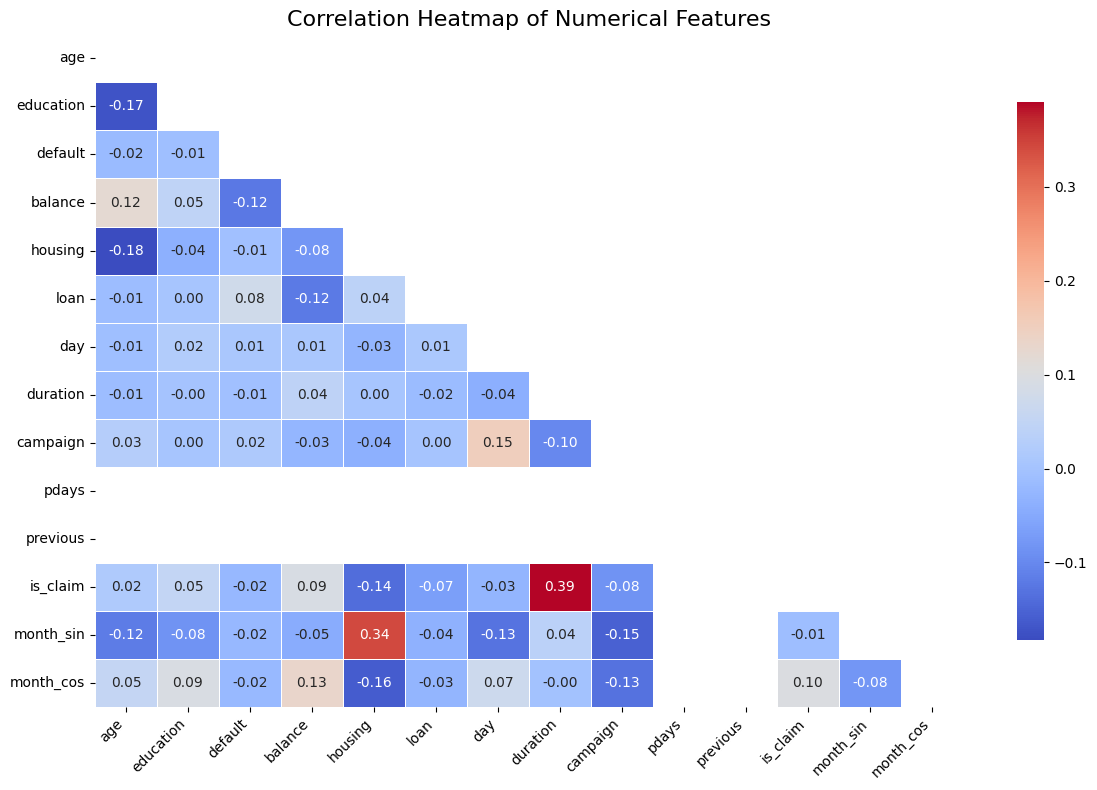

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap of Numerical Features", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

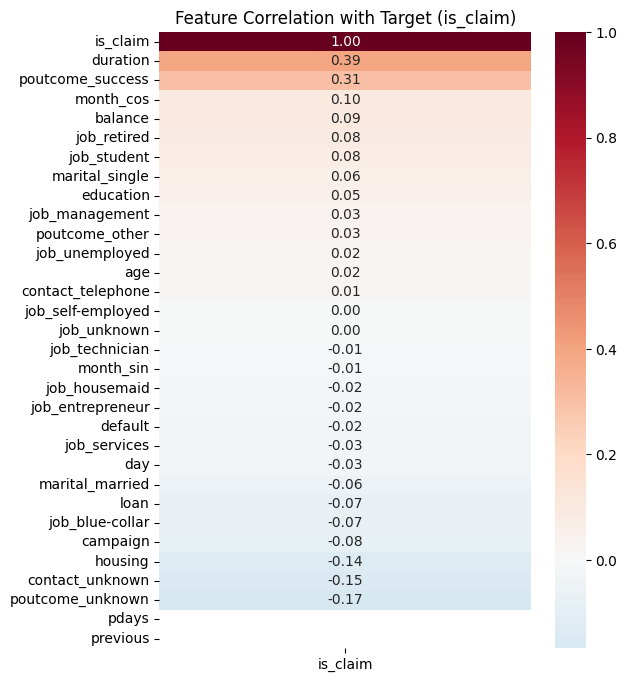

In [33]:
target_corr = bnk_dataset.corr()['is_claim'].sort_values(ascending=False)

plt.figure(figsize=(6, 8))
sns.heatmap(
    target_corr.to_frame(),
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0
)
plt.title('Feature Correlation with Target (is_claim)')
plt.show()

In [ ]:
#bnk_dataset['pdays_contacted'] = (bnk_dataset['pdays'] != 999).astype(int)
#bnk_dataset.drop(columns=['pdays'], inplace=True)

In [34]:
# Splitting the datset into training and testing dataset
X = bnk_dataset.drop(columns=['is_claim']) # input features
y = bnk_dataset['is_claim'] # Target variable

MODEL BUILDING

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibility
    stratify=y            # IMPORTANT for classification
)

Standardize using only training data

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [37]:
# importing necessary libraries using SMOTE Technique
from imblearn.over_sampling import SMOTE
# Apply SMOTE for oversampling

# intializing SMOTE function
smote = SMOTE(random_state= 42)
# Correctly pass X_train_scaled as features and y_train as the target variable
X_resampled, y_resampled = smote.fit_resample(X_train_scaled, y_train)


In [38]:
# Old class distribution
print(f" \nOld Class Distribution:", y.value_counts())
# New class distribution after SMOTE
print(f"\n New Class Distribution:", y_resampled.value_counts())


 
Old Class Distribution: is_claim
0    39922
1     5289
Name: count, dtype: int64

 New Class Distribution: is_claim
0    31937
1    31937
Name: count, dtype: int64


TRAIN MODEL WITHOUT SMOTE

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Train on original data
model_no_smote = LogisticRegression(max_iter=1000)
model_no_smote.fit(X_train, y_train)

# Predict
y_pred_no_smote = model_no_smote.predict(X_test)

print("WITHOUT SMOTE")
print(confusion_matrix(y_test, y_pred_no_smote))
print(classification_report(y_test, y_pred_no_smote))
print("Model Accuracy:", accuracy_score(y_test,y_pred_no_smote))

WITHOUT SMOTE
[[7745  240]
 [ 689  369]]
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7985
           1       0.61      0.35      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.76      0.66      0.69      9043
weighted avg       0.88      0.90      0.88      9043

Model Accuracy: 0.8972686055512551


TRAIN MODEL WITH SMOTE

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred_log = pipeline.predict(X_test)
y_score_log = pipeline.predict_proba(X_test)[:, 1] # Store probabilities for ROC curve

print("WITH SMOTE")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))
lgt_accuracy = accuracy_score(y_test, y_pred_log)
print("Accuracy:", lgt_accuracy)

WITH SMOTE
[[6554 1431]
 [ 205  853]]
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      7985
           1       0.37      0.81      0.51      1058

    accuracy                           0.82      9043
   macro avg       0.67      0.81      0.70      9043
weighted avg       0.90      0.82      0.84      9043

Accuracy: 0.8190865863098529


In [41]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        kernel='linear',          #  MUCH faster
        class_weight='balanced',  # handles imbalance
        probability=True,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred_svm = pipeline.predict(X_test)
y_score_svm = pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_svm))
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("Model Accuracy:", svm_accuracy)


              precision    recall  f1-score   support

           0       0.97      0.81      0.88      7985
           1       0.36      0.82      0.50      1058

    accuracy                           0.81      9043
   macro avg       0.67      0.81      0.69      9043
weighted avg       0.90      0.81      0.84      9043

Model Accuracy: 0.8105717129271259


In [42]:
# Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
dt_model = DecisionTreeClassifier(
    max_depth=6,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree Results")
print(classification_report(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
dcntree_accuracy = accuracy_score(y_test, y_pred_dt)
print("Model accuracy:", dcntree_accuracy)

Decision Tree Results
              precision    recall  f1-score   support

           0       0.97      0.79      0.87      7985
           1       0.35      0.84      0.49      1058

    accuracy                           0.80      9043
   macro avg       0.66      0.82      0.68      9043
weighted avg       0.90      0.80      0.83      9043

ROC-AUC: 0.886285781587168
Model accuracy: 0.7986287736370673


Random Forest Results
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.69      0.33      0.45      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043

ROC-AUC: 0.9293683927685772
Model Accuracy: 0.9042353201371226


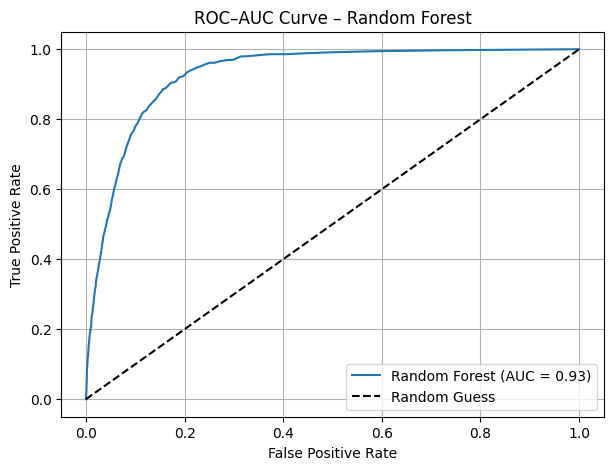

In [43]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
import matplotlib.pyplot as plt

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
rnd_forest_accuracy = accuracy_score(y_test, y_pred_rf)
print("Model Accuracy:", rnd_forest_accuracy)

# ---------------- ROC–AUC Curve ----------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC–AUC Curve – Random Forest')
plt.legend()
plt.grid()
plt.show()


In [44]:
models = pd.DataFrame({
                'Models': ['Logistic Regression','Support Vector Machine', 'Decision Tree Classifier', 'Random Forest Classifier'],
                'Score':  [lgt_accuracy, svm_accuracy, dcntree_accuracy, rnd_forest_accuracy]})

models.sort_values(by='Score', ascending=False)

,Models,Score
3,Random Forest Classifier,0.904235
0,Logistic Regression,0.819087
1,Support Vector Machine,0.810572
2,Decision Tree Classifier,0.798629


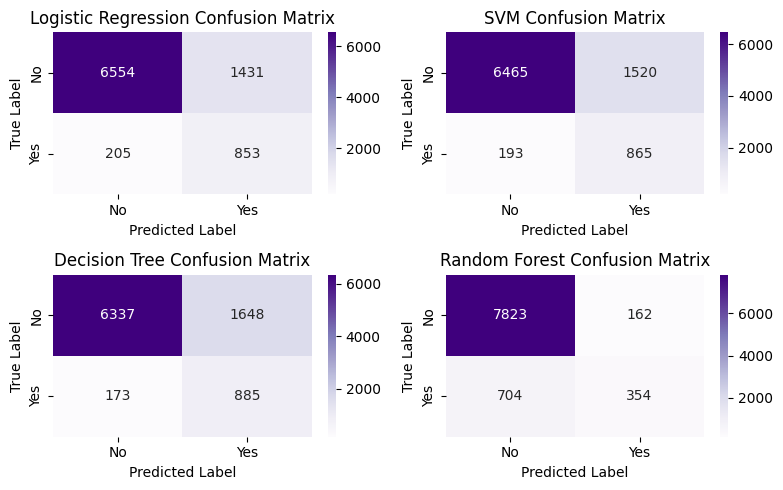

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predictions dictionary
models_preds = {
    "Logistic Regression": y_pred_log,
    "SVM": y_pred_svm,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

class_labels = ['No', 'Yes']

# Create ONE figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(8,5))
axes = axes.flatten()

# Loop through models and axes together
for ax, (name, preds) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Purples',
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax
    )

    ax.set_title(f'{name} Confusion Matrix')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.show()

MODEL SELECTION

In [46]:
# Picking a model RandomForerst Classifier

model = RandomForestClassifier(random_state =42 )
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

MODEL SAVING

In [47]:
# Save the model

# importing necessary library
import joblib

In [48]:
joblib.dump(rf_model, 'random_forest_bank_model.pkl')
print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [49]:
# Loading the saved model
loaded_rf = joblib.load('random_forest_bank_model.pkl')
print("Random Forest model loaded!")

Random Forest model loaded!


In [50]:
# Prediction on the test data
y_pred_loaded = loaded_rf.predict(X_test)

print("Loaded Model Accuracy:",
      accuracy_score(y_test, y_pred_loaded))

Loaded Model Accuracy: 0.9042353201371226


In [51]:
# Predict on  New customer
import pandas as pd

new_customer = pd.DataFrame([[
    35,      # age
    2,       # education
    0,       # default
    1500,    # balance
    1,       # housing
    0,       # loan
    15,      # day
    120,     # duration
    2,       # campaign
    999,     # pdays
    0,       # previous
    0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,   # job dummies
    1, 0,                              # marital
    0, 1,                              # contact
    0, 0, 1,                           # poutcome
    0.5, 0.86                           # month sin/cos
]], columns=X_train.columns)

In [52]:
# Predict the class and probability
prediction = loaded_rf.predict(new_customer)
probability = loaded_rf.predict_proba(new_customer)[:, 1]

print("Prediction (0 = No, 1 = Yes):", prediction[0])
print("Subscription Probability:", round(probability[0], 2))

Prediction (0 = No, 1 = Yes): 0
Subscription Probability: 0.2
